<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIOT_RF_Book_ES_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELLA 1 - Verifica versioni librerie
import sys                        # Carica i file di sistema Python
import numpy as np                # Libreria per calcoli numerici
import sklearn                    # Libreria per machine learning
import matplotlib                 # Modulo principale di matplotlib
import matplotlib.pyplot as plt   # Libreria Interfaccia di Plotting
import seaborn as sns; sns.set()  # Importa seaborn una libreria di visualizzazione dati per creare grafici statistici
import tensorflow as tf           # Importa Tensorflow

# Stampa le versioni attualmente installate di ogni libreria per verificarne la compatibilità
print("Versione Python:", sys.version)        # Verifica versione Python
print("NumPy:", np.__version__)               # Verifica versione NumPy
print("Scikit-learn:", sklearn.__version__)   # Verifica versione Scikit-learn
print("Matplotlib:", matplotlib.__version__)  # Verifica versione Matplotlib
print("Seaborn:", sns.__version__)            # Verifica versione seaborn
print("TensorFlow:", tf.__version__)          # Verifica versione TensorFlow

# Versioni richieste
# Qui definiamo le versioni specifiche delle librerie necessarie per garantire compatibilità e riproducibilità
np_version = "2.0.2"                  # Versione di NumPy desiderata
sklearn_version = "1.6.1"             # Versione Scikit-learn desiderata
matplotlib_version = "3.10.0"         # Versione Matplotlib desiderata
sns_version = "0.13.2"                # Versione Seaborn desiderata
tf_version = "2.19.0"                 # Versione TensorFlow desiderata

# Controlliamo le versioni dei pacchetti e agiamo di conseguenza
if (np.__version__ != np_version or                   # Verifica la versione di NumPy
    sklearn.__version__ != sklearn_version or         # Verifica la versione di Scikit-learn
    matplotlib.__version__ != matplotlib_version or   # Verifica la versione di Matplotlib
    sns.__version__ != sns_version or                  # Verifica versione seaborn
    tf.__version__ != tf_version):                     # Verifica la versione di TensorFlow

    # Notifica all'utente le versioni attuali e quelle che verranno installate
    print(f"Versione NumPy corrente: {np.__version__}, switching a {np_version}")
    print(f"Versione Scikit-learn corrente: {sklearn.__version__}, switching a {sklearn_version}")
    print(f"Versione Matplotlib corrente: {matplotlib.__version__}, switching a {matplotlib_version}")
    print(f"Versione Seaborn corrente: {sns.__version__}, switching a {sns_version}")
    print(f"Versione TensorFlow corrente: {tf.__version__}, switching a {tf_version}")

    # Disinstalliamo le versioni correnti dei pacchetti (se necessario)
    !pip uninstall -y numpy sklearn matplotlib seaborn tensorflow

    # Installiamo le versioni richieste dei pacchetti specificati
    !pip install numpy==2.0.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 tensorflow==2.19.0

    # Informiamo l'utente che è necessario riavviare il runtime per applicare i cambiamenti
    print("Le versioni specificate delle librerie sono state installate.")
    print("Prego cliccare su Runtime > Restart session and run all.")
else:
    # Se tutte le versioni corrispondono a quelle richieste, lo segnaliamo all'utente
    print("Tutti i pacchetti sono nelle versioni specificate")

Versione Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy: 2.0.2
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2
TensorFlow: 2.19.0
Tutti i pacchetti sono nelle versioni specificate


In [ ]:
# CELLA 2 - Carica le prime 2000 immagini 28x28 pixel per ogni cifra di MNIST
print("Caricamento MNIST con limite 2000 immagini per cifra...")

# Carica tutto il dataset MNIST che contiene immagini di cifre scritte a mano (0-9)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Combina i set di training e test in un unico dataset
X_full_temp = np.concatenate([X_train, X_test])
y_full_temp = np.concatenate([y_train, y_test])

# Liste per raccogliere le immagini selezionate
X_selected = []
y_selected = []

# Per ogni cifra (0-9), prendi le prime 1000 immagini
for digit in range(10):
    # Trova gli indici di tutte le immagini di questa cifra specifica
    digit_indices = np.where(y_full_temp == digit)[0]

    # Prendi solo le prime 2000 (o tutte se sono meno di 1000)
    selected_indices = digit_indices[:2000]

    # Aggiungi alla selezione le immagini e le etichette corrispondenti
    X_selected.extend(X_full_temp[selected_indices])
    y_selected.extend(y_full_temp[selected_indices])

    # Mostra quante immagini sono state caricate per ogni cifra
    print(f"Cifra {digit}: {len(selected_indices)} immagini caricate")

# Converti le liste in array NumPy per facilità di manipolazione
X_full = np.array(X_selected)
y_full = np.array(y_selected)

# Trasforma le immagini 28x28 in vettori piatti di 784 pixel (28*28=784)
X_flat = X_full.reshape(len(X_full), -1)

print(f"\nTotale: {len(X_full):,} immagini caricate")
print(f"{X_flat.shape[1]} pixel per immagine")

# Verifica la distribuzione finale per controllare che ogni cifra abbia 2000 campioni
print("\nDistribuzione nel dataset selezionato:")
for digit in range(10):
    count = np.sum(y_full == digit)
    print(f"  Cifra {digit}: {count:,} immagini")

Caricamento MNIST con limite 2000 immagini per cifra...
Cifra 0: 2000 immagini caricate
Cifra 1: 2000 immagini caricate
Cifra 2: 2000 immagini caricate
Cifra 3: 2000 immagini caricate
Cifra 4: 2000 immagini caricate
Cifra 5: 2000 immagini caricate
Cifra 6: 2000 immagini caricate
Cifra 7: 2000 immagini caricate
Cifra 8: 2000 immagini caricate
Cifra 9: 2000 immagini caricate

Totale: 20,000 immagini caricate
784 pixel per immagine

Distribuzione nel dataset selezionato:
  Cifra 0: 2,000 immagini
  Cifra 1: 2,000 immagini
  Cifra 2: 2,000 immagini
  Cifra 3: 2,000 immagini
  Cifra 4: 2,000 immagini
  Cifra 5: 2,000 immagini
  Cifra 6: 2,000 immagini
  Cifra 7: 2,000 immagini
  Cifra 8: 2,000 immagini
  Cifra 9: 2,000 immagini


In [ ]:
# CELLA 3 - Pre-processing delle immagini

print("\n Preprocessing...")

# Normalizzazione: converte i valori dei pixel da 0-255 a 0-1 dividendo per 255
# Questo aiuta l'algoritmo t-SNE a convergere più velocemente e stabilmente
X_normalized = X_flat / 255.0

print("Normalizzazione completata")
print(f"Dati pronti: {X_normalized.shape}")


 Preprocessing...
Normalizzazione completata
Dati pronti: (20000, 784)


In [ ]:
# CELLA 4 - Applicazione della riduzione di dimensione con t-SNE

from sklearn.manifold import TSNE  # Importa l'algoritmo t-SNE per la riduzione dimensionale

print("\n t-SNE diretto sui pixel...")

# Configura i parametri di t-SNE
tsne = TSNE(
    n_components=2,        # Riduce a 2 dimensioni per visualizzazione su piano cartesiano
    perplexity=30,         # Parametro che bilancia attenzione locale vs globale (tipicamente 5-50)
    learning_rate=200,     # Velocità di apprendimento dell'algoritmo
    n_iter=2000,           # Numero massimo di iterazioni per la convergenza
    random_state=42,       # Seed per garantire riproducibilità dei risultati
    verbose=1              # Mostra il progresso durante l'esecuzione
)

# Applica t-SNE ai dati normalizzati per ottenere coordinate 2D
coordinates_2d = tsne.fit_transform(X_normalized)

print("\n t-SNE completato")


 t-SNE diretto sui pixel...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20000 samples in 0.013s...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



[t-SNE] Computed neighbors for 20000 samples in 25.037s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20000
[t-SNE] Computed conditional probabilities for sample 2000 / 20000
[t-SNE] Computed conditional probabilities for sample 3000 / 20000
[t-SNE] Computed conditional probabilities for sample 4000 / 20000
[t-SNE] Computed conditional probabilities for sample 5000 / 20000
[t-SNE] Computed conditional probabilities for sample 6000 / 20000
[t-SNE] Computed conditional probabilities for sample 7000 / 20000
[t-SNE] Computed conditional probabilities for sample 8000 / 20000
[t-SNE] Computed conditional probabilities for sample 9000 / 20000
[t-SNE] Computed conditional probabilities for sample 10000 / 20000
[t-SNE] Computed conditional probabilities for sample 11000 / 20000
[t-SNE] Computed conditional probabilities for sample 12000 / 20000
[t-SNE] Computed conditional probabilities for sample 13000 / 20000
[t-SNE] Computed conditional probabilities for sample 14000 / 2000

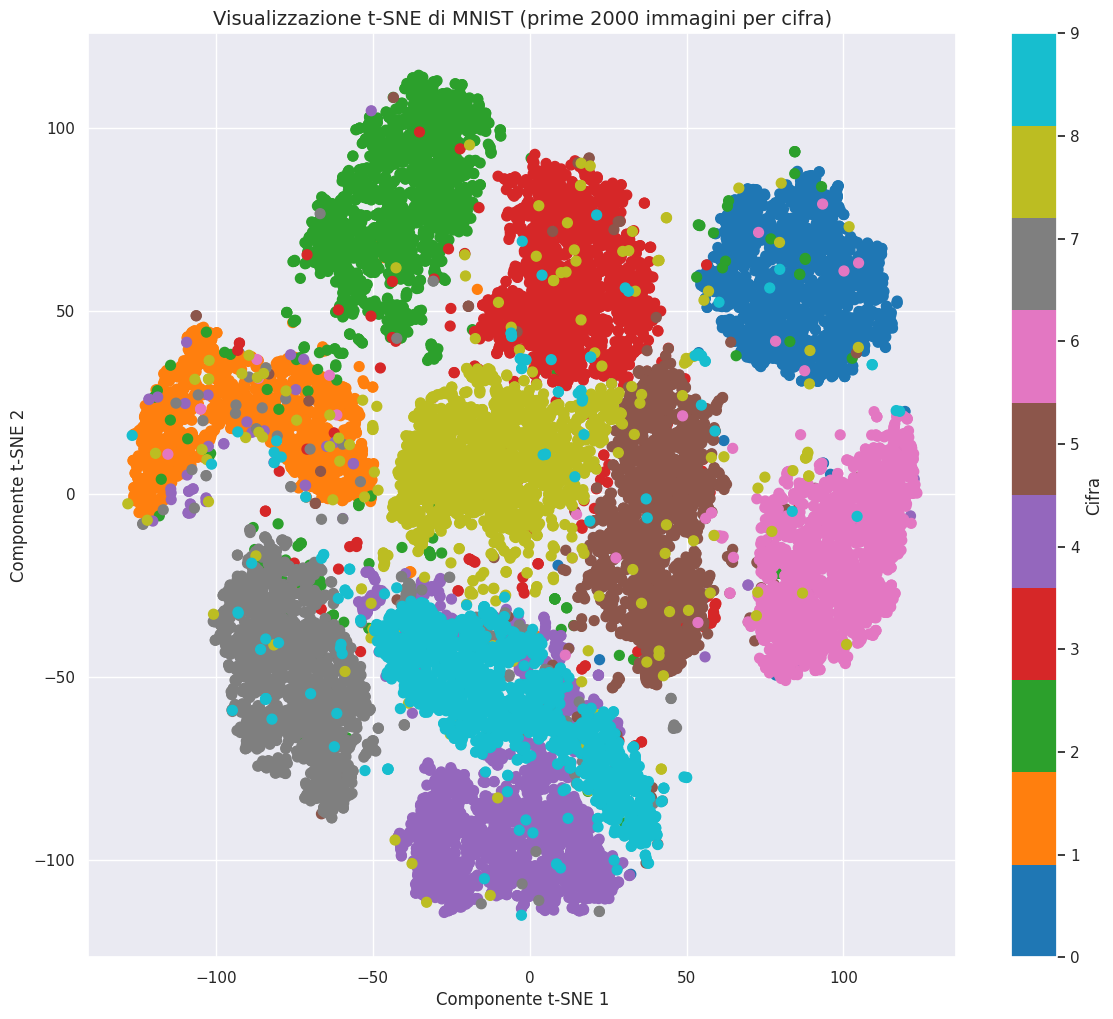

In [ ]:
# CELLA 5 - Visualizzazione dei dati dopo t-SNE, colorati per cifra originale

# Crea una figura di dimensioni 14x12 pollici per una buona visualizzazione
fig, ax = plt.subplots(figsize=(14, 12))

# Crea uno scatter plot delle coordinate t-SNE
# Ogni punto rappresenta un'immagine, colorato secondo la cifra originale (0-9)
scatter = ax.scatter(coordinates_2d[:, 0],    # Coordinate X (prima componente t-SNE)
                    coordinates_2d[:, 1],     # Coordinate Y (seconda componente t-SNE)
                    c=y_full,                 # Colori basati sulle etichette originali
                    s=50,                     # Dimensione dei punti
                    cmap='tab10')             # Mappa colori discreta per 10 cifre

# Aggiunge titolo e etichette agli assi per chiarezza
ax.set_title("Visualizzazione t-SNE di MNIST (prime 2000 immagini per cifra)", fontsize=14)
ax.set_xlabel("Componente t-SNE 1", fontsize=12)
ax.set_ylabel("Componente t-SNE 2", fontsize=12)

# Aggiunge una barra colori per mostrare la corrispondenza colore-cifra
cbar = fig.colorbar(scatter, ax=ax, ticks=np.arange(10))  # Tick per ogni cifra
cbar.set_label("Cifra", fontsize=12)
cbar.set_ticklabels(np.arange(10))  # Etichette da 0 a 9

plt.grid(True)  # Aggiunge una griglia per migliore leggibilità
plt.show()      # Mostra il grafico finale